# 08 - The metric: ROC AUC

**Concept:** why accuracy is useless in this problem, what ROC AUC actually measures and how to interpret it.

It is the evaluation metric for **the whole project**.

---

## First: why accuracy fails

Remember the imbalance: ~8% of positives. Let's build the worst possible model and measure it.

In [1]:
import sys
from pathlib import Path

# Lets us import `helpers.py` no matter where the notebook is opened from.
for _p in [Path.cwd(), Path.cwd() / "material_extra", Path.cwd().parent]:
    if (_p / "helpers.py").exists():
        sys.path.insert(0, str(_p))
        break

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import helpers

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")
print("Original dataset available:", helpers.dataset_disponible())

Original dataset available: True


In [2]:
from sklearn.metrics import accuracy_score, roc_auc_score

# We simulate a validation set with the real class imbalance
rng = np.random.default_rng(0)
y_true = (rng.random(10_000) < 0.08).astype(int)

# The most useless "model" in the world: always predict 0
useless_pred = np.zeros_like(y_true)

print(f"Accuracy of the model that says 'nobody defaults': {accuracy_score(y_true, useless_pred):.2%}")
print(f"Risky clients detected: {useless_pred.sum()} out of {y_true.sum()}")
print()
print("A 92% accuracy... and zero business value.")

Accuracy of the model that says 'nobody defaults': 91.85%
Risky clients detected: 0 out of 815

A 92% accuracy... and zero business value.


> **Rule:** with imbalanced classes, accuracy mostly measures **how imbalanced the dataset is**, not how good the model is.

## What ROC AUC measures

The ROC curve sweeps through **every possible threshold** and plots:

- **TPR** (*True Positive Rate*, or recall) = out of everyone who did default, what fraction did I detect?
- **FPR** (*False Positive Rate*) = out of everyone who paid back properly, what fraction did I reject by mistake?

The **AUC** is the area under that curve.

### The interpretation you can understand without formulas

> **The AUC is the probability that, if you pick at random one client who defaulted and one who did not, the model assigns a higher score to the one who defaulted (that is, if 1 means default, that it gives them a 1 and not a 0).**

| AUC | Meaning |
|---|---|
| 0.5 | Pure chance (coin flip) |
| 0.6 – 0.7 | Weak but useful |
| **0.7 – 0.8** | **Typical range in credit scoring** ← this project |
| 0.8 – 0.9 | Very good |
| > 0.95 | Suspect leakage 🚩 |

### Let's check it with 4 clients

That sentence talks about **pairs**: you always take *two* clients, one from each class. With 4 clients we can go through every pair by hand and compare the result against `roc_auc_score()`.

In [3]:
# 4 clients: 2 defaulted (1) and 2 paid back properly (0)
example = pd.DataFrame({
    "client":  ["A", "B", "C", "D"],
    "default": [1, 1, 0, 0],
    "score":   [0.70, 0.40, 0.50, 0.20],
})
print(example.to_string(index=False))

# Every possible pair (one defaulter against one non-defaulter)
print("\nIn each pair, did the one who defaulted get the higher score?\n")
correct = 0
for _, p in example[example["default"] == 1].iterrows():
    for _, n in example[example["default"] == 0].iterrows():
        ok = p["score"] > n["score"]
        correct += ok
        print(f"  {p['client']} ({p['score']:.2f})  vs  {n['client']} ({n['score']:.2f})"
              f"   ->  {'YES, well ranked' if ok else 'NO, badly ranked'}")

print(f"\nWell-ranked pairs: {correct} out of 4  ->  {correct / 4:.2f}")
print(f"roc_auc_score()  : {roc_auc_score(example['default'], example['score']):.2f}")

client  default  score
     A        1    0.7
     B        1    0.4
     C        0    0.5
     D        0    0.2

In each pair, did the one who defaulted get the higher score?

  A (0.70)  vs  C (0.50)   ->  YES, well ranked
  A (0.70)  vs  D (0.20)   ->  YES, well ranked
  B (0.40)  vs  C (0.50)   ->  NO, badly ranked
  B (0.40)  vs  D (0.20)   ->  YES, well ranked

Well-ranked pairs: 3 out of 4  ->  0.75
roc_auc_score()  : 0.75


The AUC **is** exactly that: the proportion of pairs the model ranked correctly.

> **And with 10,000 clients?** There the possible pairs are in the millions, but `roc_auc_score()` does not walk through them one by one: it sorts the scores from highest to lowest and computes the area under the ROC curve, which gives **exactly** the same number. It is an exact, deterministic computation: call it a thousand times and it always returns the same value.

The key takeaway: **no threshold ever appears** in the computation. It only compares who scored higher than whom, so the AUC measures the quality of the **ranking** of clients, not of a single decision.

## Drawing the ROC curve

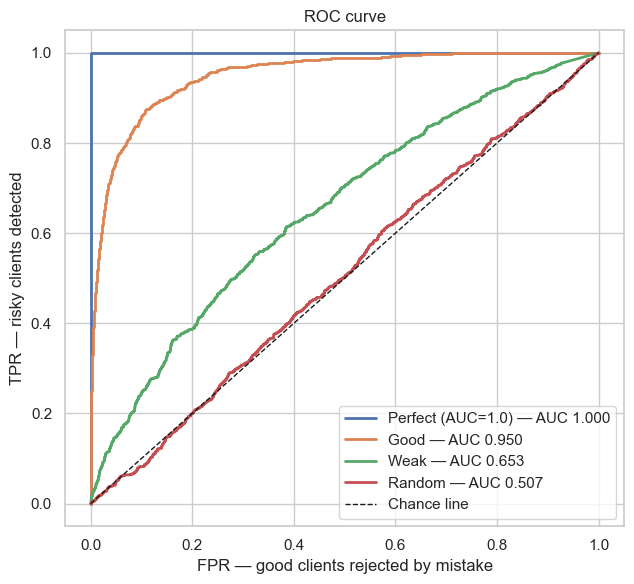

In [4]:
from sklearn.metrics import roc_curve

models = {
    "Perfect (AUC=1.0)": y_true + rng.random(len(y_true)) * 0.01,
    "Good": np.clip(rng.normal(0.3 + 0.35 * y_true, 0.15), 0, 1),
    "Weak": np.clip(rng.normal(0.3 + 0.12 * y_true, 0.20), 0, 1),
    "Random": rng.random(len(y_true)),
}

fig, ax = plt.subplots(figsize=(6.5, 6))
for name, s in models.items():
    fpr, tpr, _ = roc_curve(y_true, s)
    ax.plot(fpr, tpr, lw=2, label=f"{name} — AUC {roc_auc_score(y_true, s):.3f}")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance line")
ax.set_xlabel("FPR — good clients rejected by mistake")
ax.set_ylabel("TPR — risky clients detected")
ax.set_title("ROC curve")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### How to read the curve

Every point on the curve is **one decision threshold**. Moving along the curve is the business decision:

- Upper right → you approve few: you detect almost every risky client, but you reject many good ones.
- Lower left → you approve almost everything: you bother nobody, but you eat the defaults.

**The AUC summarizes the quality of the model regardless of where you put the threshold.** Choosing the threshold is a later decision, and a business one, not an ML one.

## From score to threshold: the business decision

In [5]:
fpr, tpr, thresholds = roc_curve(y_true, models["Good"])

table = pd.DataFrame({"threshold": thresholds, "TPR_detected": tpr, "FPR_wrongly_rejected": fpr})
selection = table.iloc[np.linspace(1, len(table) - 1, 8).astype(int)]
print("Each row is a different approval policy with the SAME model:\n")
print(selection.round(3).to_string(index=False))

Each row is a different approval policy with the SAME model:

 threshold  TPR_detected  FPR_wrongly_rejected
     1.000         0.009                 0.000
     0.678         0.426                 0.008
     0.612         0.580                 0.019
     0.574         0.696                 0.033
     0.540         0.773                 0.054
     0.490         0.859                 0.100
     0.428         0.931                 0.192
     0.000         1.000                 1.000


In a real case, the row you pick comes from comparing **the cost of a default** (you lose the loaned capital) against **the cost of rejecting a good client** (you lose the loan's margin).


## Common mistakes when measuring

| Mistake | Consequence |
|---|---|
| Using `predict()` instead of `predict_proba()[:, 1]` | The AUC is computed over 0/1 and drops artificially |
| Passing column `[:, 0]` | Inverted AUC (~1 - real AUC) |
| Swapping the order: `roc_auc_score(y_score, y_true)` | Meaningless result |
| Measuring only on train | You don't catch overfitting → notebook 09 |

---

## Exercises

1. Compute the AUC of your model from notebook 07 using `predict()` instead of `predict_proba()[:, 1]`. How much do you lose? Why exactly?
2. If the bank loses \$10,000 for every approved default and earns \$800 for every well-granted loan, what is the optimal threshold? Write the cost function and find it with `roc_curve`.
3. Look into the **Gini coefficient**, widely used in the credit industry: `Gini = 2 × AUC - 1`. What Gini does the project's final model have (AUC 0.7313)?
4. Compute the `average_precision_score` of your model from notebook 07. Does it tell the same story as the AUC?

In [6]:
# Your turn
